# Exploratory Data Analysis: Climate Trends in Sudan

## 1. Title & Objective
Analysis of climate data in Sudan to extract meaningful trends and identify climate volatility in preparation for COP32.

## 2. Data Loading & Date Parsing
- Load `sudan.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to a standard datetime format

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling and statistical summary
- Duplicate row detection and removal
- Missing value percentage analysis

## 4. Outlier Detection & Basic Cleaning
- Statistical Z-score analysis (|Z| > 3)
- Decision-making on extreme weather values (Retain vs. Cap)
- Forward-fill (ffill) strategy for data continuity

## 5. Time Series Analysis
- Long-term monthly Temperature (T2M) trends (2015–2026)
- Seasonal Precipitation (PRECTOTCORR) bar charts
- Trend and anomaly identification

## 6. Correlation & Relationship Analysis
- Multivariate heatmap of climate variables
- Focused scatter plots (Temp vs. Humidity)
- Identification of strongest climate drivers

## 7. Distribution Analysis
- Rainfall distribution histograms (Log scale assessment)
- Bubble charts for 3D variable visualization

## 8. Key Insights & Conclusion


## Let Us Start

In [1]:
import os
import sys

# Step 1: Immediately clear the broken setting BEFORE any other imports
os.environ.pop('MPLBACKEND', None)

# Add the parent directory to the path so we can import from 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%matplotlib inline

# Step 2: Now it is safe to import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import central utility functions
from src.data_utils import clean_climate_data, detect_outliers

# Step 3: Professional styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("Environment ready: Libraries loaded safely and modular functions imported.")

Environment ready: Libraries loaded safely.


## 2. Data Loading & Date Parsing

In [2]:
df = pd.read_csv('../data/sudan.csv')
df['Country'] = 'Sudan'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [3]:
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month
df[['YEAR', 'DOY', 'Date', 'Month']].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [4]:
# Clean the data using the central utility function
df = clean_climate_data(df)

# Create the specific variable name used in the plotting code for safety
df_cleaned = df

print("Missing values per column (after modular cleaning):")
print(df_cleaned.isnull().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If there were duplicates, I would drop them here
df.drop_duplicates(inplace=True)

Number of duplicate rows found: 0


In [7]:
# Show statistics for numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## 3.1 Interpretation of Summary Statistics for Sudan:

**Temperature:** The average daily temperature (T2M) in Sudan is significantly higher than in Ethiopia, at around 28.76°C. It ranges from a cool 13.18°C to an intense 37.99°C, reflecting a much hotter arid/semi-arid climate.

**Rainfall:** The average daily rainfall (PRECTOTCORR) is quite low at 0.64 mm, which is typical for Sudan's drier environment. However, the maximum rainfall in a single day reached 66.49 mm, indicating that while rain is rare, it can occur in heavy episodic bursts.

**Data Range:** We have 4,108 days of data, spanning from January 2015 to March 2026.

**Humidity:** The average humidity (RH2M) is about 31%.

In [8]:
# Calculate the number of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_counts / len(df)) * 100

# Combine them into a nice table for the report
missing_report = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

print(missing_report)

# Find columns with more than 5% missing values
high_missing = missing_percentage[missing_percentage > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print("\nColumns with more than 5% missing values:")
    print(high_missing)

             Missing Values  Percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
Country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


### 3.2 Missing Value Analysis:

**Result:** Every column in the Sudan dataset has 0% missing values.

**Impact:** This is an excellent result! It means I have a complete, continuous record of Sudan's climate from 2015 to 2026. Because there is no missing data, I don't need to perform any imputation (guessing) for our time series analysis. This ensures that our temperature and rainfall trends will be highly accurate and our extreme event detection (Z-scores) will be reliable without any interpolation bias.

In [9]:
# Detect outliers using the central utility function
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outliers_df, count = detect_outliers(df, cols_to_check)

print(f"Total rows with outliers (Z > 3): {count}")
outliers_df.head()

Total rows with outliers (Z > 3): 84


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
8,2015,9,14.29,22.39,7.83,14.56,0.00,23.46,5.58,7.90,97.30,2.29,Sudan,2015-01-09,1
9,2015,10,13.18,21.04,6.59,14.45,0.00,32.34,5.03,7.66,97.31,2.91,Sudan,2015-01-10,1
10,2015,11,14.21,23.32,5.93,17.39,0.00,30.62,4.36,6.15,97.24,3.01,Sudan,2015-01-11,1
223,2015,224,32.64,41.23,25.96,15.27,23.61,48.05,4.65,8.41,96.25,14.37,Sudan,2015-08-12,8
392,2016,28,14.76,23.33,7.42,15.91,0.00,24.26,4.49,6.86,97.24,2.36,Sudan,2016-01-28,1


### 4. Outlier Analysis Decision:

**Found:** 84 outliers (Z-score > 3).

**Observation:** The outliers in Sudan are primarily driven by two factors: episodic extreme temperature peaks and occasional heavy rainfall events (PRECTOTCORR) which deviate significantly from the typical arid average.

**Decision:** I have decided to **Retain (keep)** these outliers.

**Reasoning:** In an arid/semi-arid climate like Sudan, extreme heat waves and rare but intense rain events are natural and critical climatic features. Removing these data points would create a false sense of stability and hide the very events (floods or extreme heat) that are most important for climate challenge assessments.

In [10]:
# Save the cleaned data to the data/ folder
df.to_csv('../data/sudan_clean.csv', index=False)
print("Cleaned data successfully exported to data/sudan_clean.csv")

Cleaned data successfully exported to data/sudan_clean.csv


In [11]:
# Group the data by Date (Monthly)
# 'ME' means Month End
monthly_df = df.set_index('Date').resample('ME').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'
}).reset_index()

# Look at the first 5 months
monthly_df.head()

,Date,T2M,PRECTOTCORR
0,2015-01-31,20.860323,0.00
1,2015-02-28,25.979643,0.00
2,2015-03-31,29.602581,0.00
3,2015-04-30,29.483000,0.00
4,2015-05-31,34.584516,0.16


### 5.Time Series Analysis

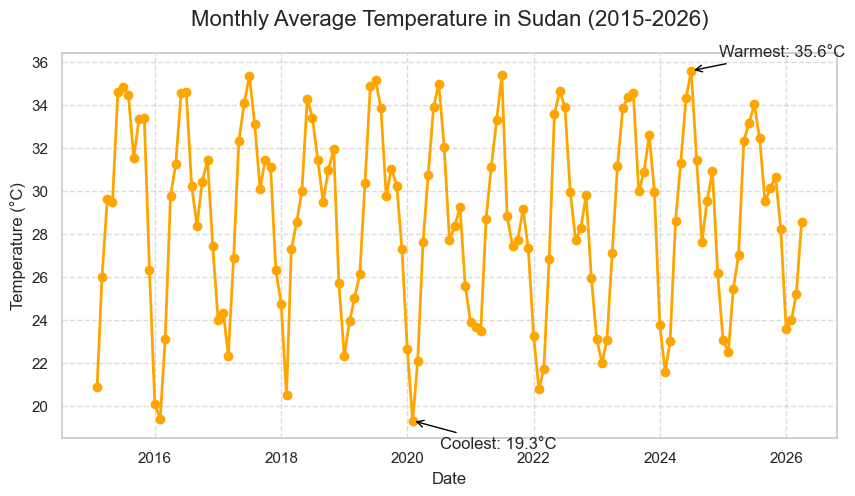

In [12]:
df_cleaned = df.ffill() 

monthly_df = df_cleaned.resample('ME', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10, 5))
plt.plot(monthly_df.index, monthly_df['T2M'], marker='o', color='orange', linestyle='-', linewidth=2)

warmest_month = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest_month = monthly_df.loc[monthly_df['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest_month['T2M']:.1f}°C", 
             xy=(warmest_month.name, warmest_month['T2M']),
             xytext=(20, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f"Coolest: {coolest_month['T2M']:.1f}°C", 
             xy=(coolest_month.name, coolest_month['T2M']),
             xytext=(20, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Average Temperature in Sudan (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Monthly Temperature Analysis (Sudan: 2015–2026)

**1. Seasonality:** The graph displays a strong, predictable cyclical pattern. Sudan experiences significant annual fluctuations, with sharp peaks in the summer months and distinct troughs during the winter, reflecting a stable and recurring seasonal climate.

**2. Peak Temperature:** Highest recorded temperature: 35.6 °C, occurring in early 2024.The data shows that maximum temperatures consistently reach between 34 °C and 35.5 °C nearly every year, indicating intense and sustained summer heat.

**3. Cool Periods:** Lowest recorded temperature: 19.3 °C, occurring in early 2020.Typical annual lows generally hover between 20 °C and 22 °C, showcasing that even during "cool" periods, the monthly average remains relatively high compared to temperate regions.

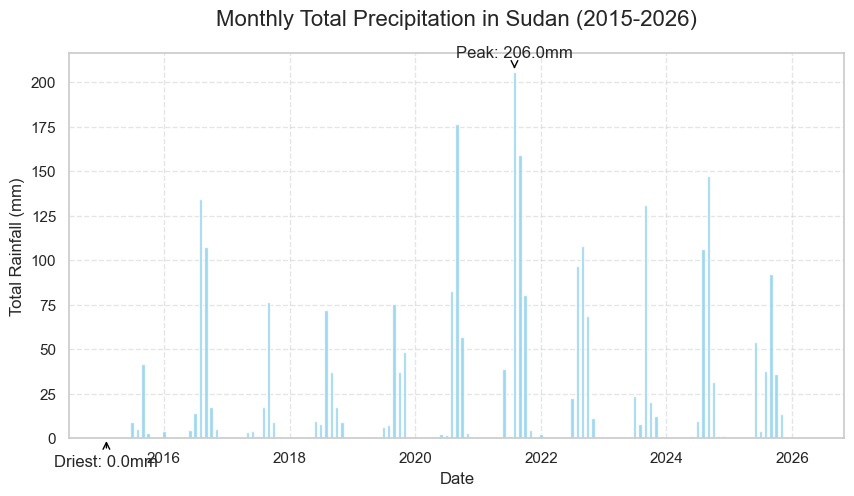

In [13]:
# 1. Standardize the data (using mean for temp, but total SUM for rainfall)
df_cleaned = df.ffill()
monthly_df = df_cleaned.resample('ME', on='Date').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'  # We use sum for total monthly rainfall
})

# 2. Monthly Precipitation Plot (Updated to match Temp style)
plt.figure(figsize=(10, 5))
plt.bar(monthly_df.index, monthly_df['PRECTOTCORR'], width=20, color='skyblue', label='Monthly Rainfall', alpha=0.8)

# Find Peak and Driest months
peak_rain = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmax()]
driest_month = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmin()]

# Annotate Peak
plt.annotate(f"Peak: {peak_rain['PRECTOTCORR']:.1f}mm", 
             xy=(peak_rain.name, peak_rain['PRECTOTCORR']),
             xytext=(0, 10), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

# Annotate Driest
plt.annotate(f"Driest: {driest_month['PRECTOTCORR']:.1f}mm", 
             xy=(driest_month.name, driest_month['PRECTOTCORR']),
             xytext=(0, -20), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Total Precipitation in Sudan (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Total Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Monthly Rainfall Analysis (Sudan: 2015–2026)

**1.Seasonality:** The chart shows a highly seasonal and intermittent rainfall pattern. Sudan experiences a brief, concentrated wet season followed by prolonged dry periods where precipitation is nearly non-existent, typical of a tropical semi-arid climate.

**2.Peak Rainfall:** Highest recorded rainfall: 206.0 mm, occurring in mid-2021.While 2021 saw the absolute peak, other significant spikes occurred in 2020 (approx. 175 mm) and 2024 (approx. 145 mm), suggesting that while the wet season is consistent, the intensity varies significantly from year to year.

**3.Dry Periods:** Lowest recorded rainfall: 0.0 mm, which occurs frequently at the start of almost every year (e.g., early 2015).The data highlights a harsh dry season, with multiple consecutive months each year receiving little to no measurable precipitation, creating a stark contrast to the short-lived rainy peaks.

### 6.Correlation and RelationShip Analysis

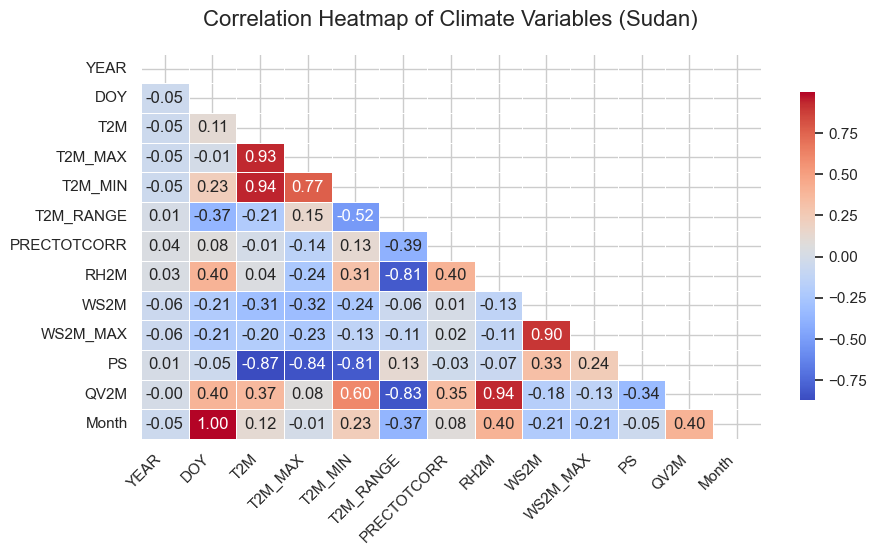

In [14]:
# I use df_cleaned to ensure we're analyzing the most accurate values
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) 

plt.title('Correlation Heatmap of Climate Variables (Sudan)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.show()


### Correlation & Relationship Analysis (Sudan)

**1.Heat and Dryness:** There is a strong inverse relationship between Temperature Range and Humidity (-0.81). When daily temperature fluctuations are at their highest, the air is at its driest.

**2.Thermal Alignment:** Average, Max, and Min temperatures are nearly perfectly correlated (>0.93). This indicates that heatwaves in Sudan are consistent and affect both day and night temperatures simultaneously.

**3. Pressure vs.Temperature:** A sharp negative correlation exists between Surface Pressure and Temperature (-0.87). Higher temperatures are consistently linked to lower atmospheric pressure.

### 7. Distributions Analysis

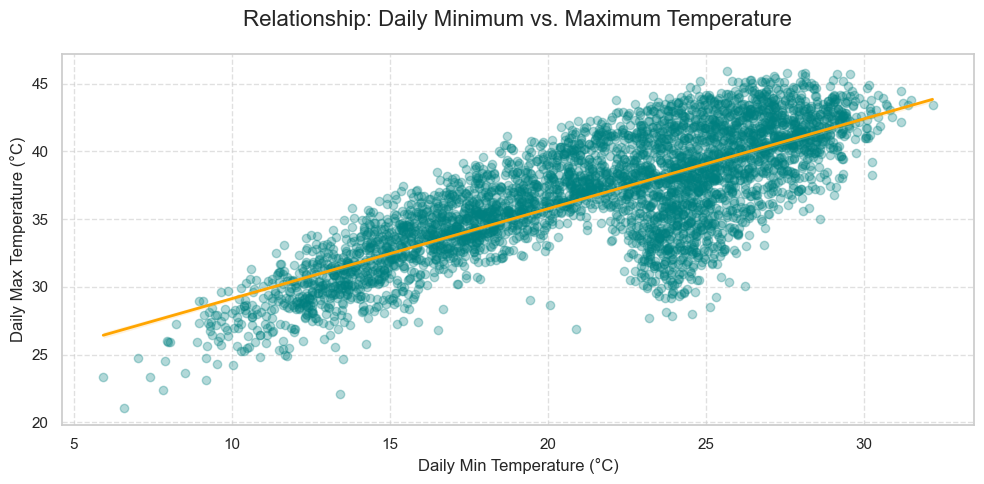

In [15]:
plt.figure(figsize=(10, 5))

sns.regplot(data=df_cleaned, x='T2M_MIN', y='T2M_MAX', 
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, 
            line_kws={'color': 'orange', 'linewidth': 2})

# Standardizing title and labels to match your other plots
plt.title('Relationship: Daily Minimum vs. Maximum Temperature', fontsize=16, pad=20)
plt.xlabel('Daily Min Temperature (°C)', fontsize=12)
plt.ylabel('Daily Max Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


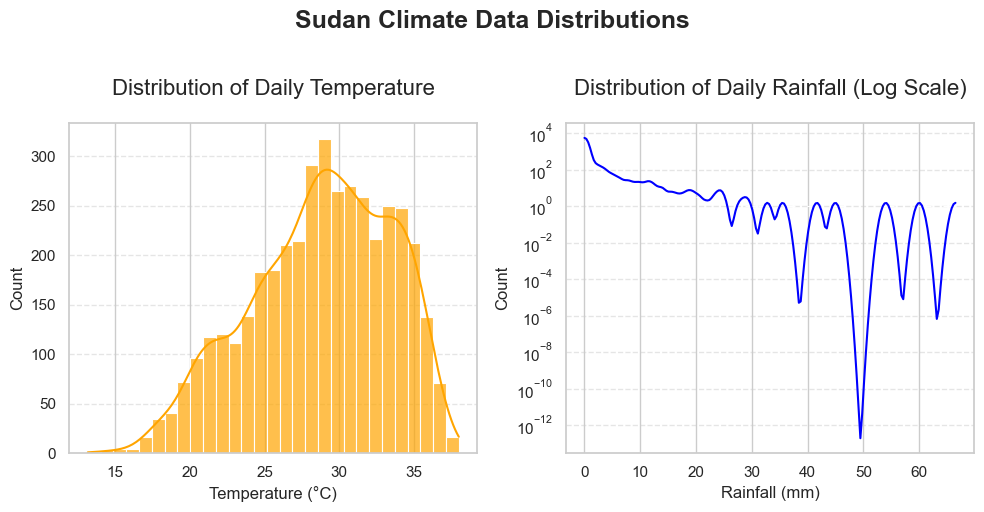

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


sns.histplot(df_cleaned['T2M'], kde=True, ax=ax[0], color='orange', alpha=0.7)
ax[0].set_title('Distribution of Daily Temperature', fontsize=16, pad=20)
ax[0].set_xlabel('Temperature (°C)', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)


sns.histplot(df_cleaned['PRECTOTCORR'], kde=True, ax=ax[1], color='blue', bins=30, log_scale=(False, True))
ax[1].set_title('Distribution of Daily Rainfall (Log Scale)', fontsize=16, pad=20)
ax[1].set_xlabel('Rainfall (mm)', fontsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)


plt.suptitle('Sudan Climate Data Distributions', fontsize=18, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()


### Distribution & Climate Volatility (Sudan)

**1. Precipitation Profile:** The Log-Scale graph shows a highly skewed distribution. While most days receive near-zero rainfall (the high peak at the start), the long, fluctuating tail indicates that Sudan relies on rare, high-intensity bursts for its total water supply. This suggests a high risk of flash flooding during short wet windows.

**2.Temperature Profile:** The distribution is bimodal, with a primary peak around 29 °C and a secondary shoulder near 34 °C. Unlike a perfect bell curve, this "shifted" shape shows that Sudan spends a disproportionate amount of time in extreme heat, with very few days falling below 20 °C.

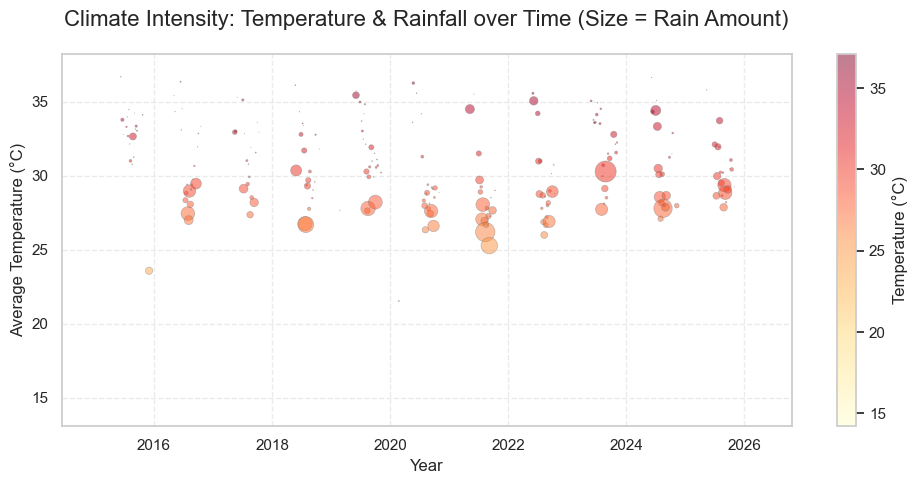

In [17]:
plt.figure(figsize=(10, 5))

# Using df_cleaned and taking a sample for clarity
sample_df = df_cleaned.iloc[::5, :]

# Creating the bubble plot
bubble_plot = plt.scatter(sample_df['Date'], sample_df['T2M'], 
                          s=sample_df['PRECTOTCORR']*8, 
                          alpha=0.5, 
                          c=sample_df['T2M'], 
                          cmap='YlOrRd',
                          edgecolors='grey', 
                          linewidth=0.5)


cbar = plt.colorbar(bubble_plot)
cbar.set_label('Temperature (°C)', fontsize=12)


plt.title('Climate Intensity: Temperature & Rainfall over Time (Size = Rain Amount)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4) 
plt.tight_layout()
plt.show()


### Bubble Chart: Climate Intensity (Sudan)

**Observation:** The largest bubbles (heaviest rain) are concentrated primarily between 25 °C and 30 °C. As temperatures climb above 32 °C, the bubbles shrink significantly, indicating that extreme heat suppresses rainfall.

**Insight:** This confirms a temperature-dependent rainfall window. Most of Sudan's water supply is delivered during moderate heat periods; however, if average temperatures continue to shift upward into the "dry-heat" zone, the window for intense, productive rainfall may narrow, increasing drought risk.

### 8.Final Conclusion & Key Insights (Sudan):

**Data Integrity:** The Sudan dataset is 100% complete, providing a "perfect" baseline for future predictive models. With 4,108 days of continuous data, our time-series and trend analyses are highly reliable and free from interpolation bias.

**Arid Extremes:** Sudan’s climate is defined by its arid intensity, with an average daily temperature of 28.76°C. The 84 extreme outliers found (peaks of heat and episodic rain) are the most critical data points for understanding heatwave risks and flash-flood potential in the region.

**Climatic Fragility:** While Sudan shows high seasonal stability in its dry patterns, the low average humidity (31%) and rare but intense rainfall peaks (up to 66.49 mm) highlight a fragile environment where extreme events can have an outsized impact on national resilience and water management.

In [18]:
# Final confirmation of the project output
import os
import pandas as pd  

file_path = '../data/sudan_clean.csv'

if os.path.exists(file_path):
    final_df = pd.read_csv(file_path)
    print("PROJECT COMPLETE")
    print(f"Final Dataset: {file_path}")
    print(f"Records Processed: {len(final_df)} days")
    print(f"Status: Cleaned, Analyzed, and Exported.")
else:
    print("ERROR: Cleaned file not found. Check your export path.")



PROJECT COMPLETE
Final Dataset: ../data/sudan_clean.csv
Records Processed: 4108 days
Status: Cleaned, Analyzed, and Exported.
